In [1]:
"""
DCGAN para geração de rostos — dataset CelebA.
"""
import os
import shutil

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

In [2]:
# --- Configurações ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 64
BATCH_SIZE = 32
LATENT_DIM = 100
NUM_EPOCHS = 50
LR_DISCRIMINATOR = 1e-4
LR_GENERATOR = 3e-4
BETAS = (0.5, 0.999)
REAL_LABEL_SMOOTHING = 0.9
CHECKPOINT_EVERY = 10
N_IMAGES_SAMPLE = 50_000

SOURCE_DATASET = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"
WORKING_ROOT = "/kaggle/working/faces"
WORKING_DATA = "/kaggle/working/faces/faces"


def prepare_dataset(source: str, target_root: str, target_folder: str, n_images: int) -> None:
    """Copia uma amostra do dataset para a pasta de trabalho (ImageFolder exige subpasta de classe)."""
    if os.path.isdir(target_folder) and os.listdir(target_folder):
        print(f"Dataset já preparado em '{target_folder}', pulando cópia.")
        return

    if not os.path.isdir(source):
        raise FileNotFoundError(f"Diretório fonte não encontrado: '{source}'.")

    os.makedirs(target_folder, exist_ok=True)
    files = os.listdir(source)[:n_images]
    for filename in files:
        shutil.copy(os.path.join(source, filename), os.path.join(target_folder, filename))
    print(f"{len(files)} imagens copiadas para '{target_folder}'.")


def build_dataloader(data_root: str, image_size: int, batch_size: int) -> DataLoader:
    """Cria o DataLoader com as transformações padrão de uma DCGAN."""
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
    dataset = ImageFolder(root=data_root, transform=transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)


class Generator(nn.Module):
    """Gera imagens 64x64x3 a partir de um vetor de ruído latente."""

    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.main(x)


class Discriminator(nn.Module):
    """Classifica imagens 64x64x3 como reais (1) ou falsas (0)."""

    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.main(x)


def train(netG, netD, dataloader, num_epochs, latent_dim, device, checkpoint_every=CHECKPOINT_EVERY):
    """Executa o loop de treinamento adversarial. Retorna as losses e as amostras geradas por época."""
    criterion = nn.BCELoss()
    optimizer_d = optim.Adam(netD.parameters(), lr=LR_DISCRIMINATOR, betas=BETAS)
    optimizer_g = optim.Adam(netG.parameters(), lr=LR_GENERATOR, betas=BETAS)

    fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)
    g_losses, d_losses, img_list = [], [], []

    try:
        for epoch in range(num_epochs):
            for i, (real_images, _) in enumerate(dataloader):
                real_images = real_images.to(device)
                b_size = real_images.size(0)

                real_labels = torch.full((b_size,), REAL_LABEL_SMOOTHING, device=device)
                fake_labels = torch.zeros(b_size, device=device)

                # --- Discriminador ---
                netD.zero_grad()
                output_real = netD(real_images).view(-1)
                loss_real = criterion(output_real, real_labels)
                loss_real.backward()

                noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
                fake_images = netG(noise)
                output_fake = netD(fake_images.detach()).view(-1)
                loss_fake = criterion(output_fake, fake_labels)
                loss_fake.backward()

                loss_d = loss_real + loss_fake
                optimizer_d.step()

                # --- Gerador ---
                netG.zero_grad()
                output = netD(fake_images).view(-1)
                loss_g = criterion(output, real_labels)
                loss_g.backward()
                optimizer_g.step()

                if i % 100 == 0:
                    print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{i}/{len(dataloader)}] "
                          f"Loss D: {loss_d.item():.4f} Loss G: {loss_g.item():.4f}")

                g_losses.append(loss_g.item())
                d_losses.append(loss_d.item())

            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(make_grid(fake, padding=2, normalize=True))

            # Checkpoint a cada N épocas (corrigido: no original estava fora do loop e nunca rodava)
            if (epoch + 1) % checkpoint_every == 0:
                torch.save(netG.state_dict(), f"generator_epoch_{epoch+1}.pth")
                print(f"Checkpoint salvo: generator_epoch_{epoch+1}.pth")

    except Exception as exc:
        raise RuntimeError(f"Falha durante o treinamento da GAN: {exc}") from exc

    return g_losses, d_losses, img_list


def plot_losses(g_losses, d_losses):
    """Plota a evolução das losses do Gerador e Discriminador."""
    plt.figure(figsize=(10, 5))
    plt.title("Generator and Discriminator Loss During Training")
    plt.plot(g_losses, label="Generator")
    plt.plot(d_losses, label="Discriminator")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


def plot_generated(img_list):
    """Exibe a última amostra de imagens geradas pelo Gerador."""
    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title("Imagens Geradas")
    plt.imshow(np.transpose(img_list[-1], (1, 2, 0)))
    plt.show()


def plot_real_vs_generated(real_batch, img_list):
    """Compara lado a lado uma amostra de imagens reais e geradas."""
    plt.figure(figsize=(15, 15))

    plt.subplot(1, 2, 1)
    plt.axis("off")
    plt.title("Imagens Reais")
    plt.imshow(np.transpose(make_grid(real_batch[:64], padding=2, normalize=True).cpu(), (1, 2, 0)))

    plt.subplot(1, 2, 2)
    plt.axis("off")
    plt.title("Imagens Geradas")
    plt.imshow(np.transpose(img_list[-1], (1, 2, 0)))
    plt.show()


def test_discriminator(netD, netG, dataloader, latent_dim, device, n_samples=8):
    """Testa o Discriminador já treinado em uma mistura de imagens reais e geradas."""
    netD.eval()
    netG.eval()

    real_images = next(iter(dataloader))[0][:n_samples].to(device)
    noise = torch.randn(n_samples, latent_dim, 1, 1, device=device)
    fake_images = netG(noise)

    all_images = torch.cat([real_images, fake_images])
    true_labels = ["REAL"] * n_samples + ["FAKE"] * n_samples

    with torch.no_grad():
        outputs = netD(all_images).view(-1)

    plt.figure(figsize=(16, 16))
    for i in range(n_samples * 2):
        img = all_images[i].cpu() * 0.5 + 0.5
        img = np.transpose(img.detach().numpy(), (1, 2, 0))
        prediction = outputs[i].item()
        predicted_label = "REAL" if prediction > 0.5 else "FAKE"

        plt.subplot(4, 4, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Real: {true_labels[i]}\nIA: {predicted_label}\nConfiança: {prediction:.2f}")
    plt.tight_layout()
    plt.show()

Dataset já preparado em '/kaggle/working/faces/faces', pulando cópia.
Epoch [1/50] Batch [0/1563] Loss D: 1.4591 Loss G: 1.7843
Epoch [1/50] Batch [100/1563] Loss D: 1.1871 Loss G: 3.0445
Epoch [1/50] Batch [200/1563] Loss D: 1.3906 Loss G: 3.5822
Epoch [1/50] Batch [300/1563] Loss D: 1.2374 Loss G: 1.8953
Epoch [1/50] Batch [400/1563] Loss D: 1.0095 Loss G: 1.6225
Epoch [1/50] Batch [500/1563] Loss D: 0.9529 Loss G: 2.4160
Epoch [1/50] Batch [600/1563] Loss D: 1.1034 Loss G: 1.6024
Epoch [1/50] Batch [700/1563] Loss D: 1.4775 Loss G: 2.6881
Epoch [1/50] Batch [800/1563] Loss D: 1.0720 Loss G: 2.3337
Epoch [1/50] Batch [900/1563] Loss D: 1.5757 Loss G: 1.3009
Epoch [1/50] Batch [1000/1563] Loss D: 1.2047 Loss G: 1.4639
Epoch [1/50] Batch [1100/1563] Loss D: 0.9598 Loss G: 2.0300
Epoch [1/50] Batch [1200/1563] Loss D: 1.0969 Loss G: 1.2829
Epoch [1/50] Batch [1300/1563] Loss D: 0.9820 Loss G: 1.8926
Epoch [1/50] Batch [1400/1563] Loss D: 0.9671 Loss G: 2.1235
Epoch [1/50] Batch [1500/15

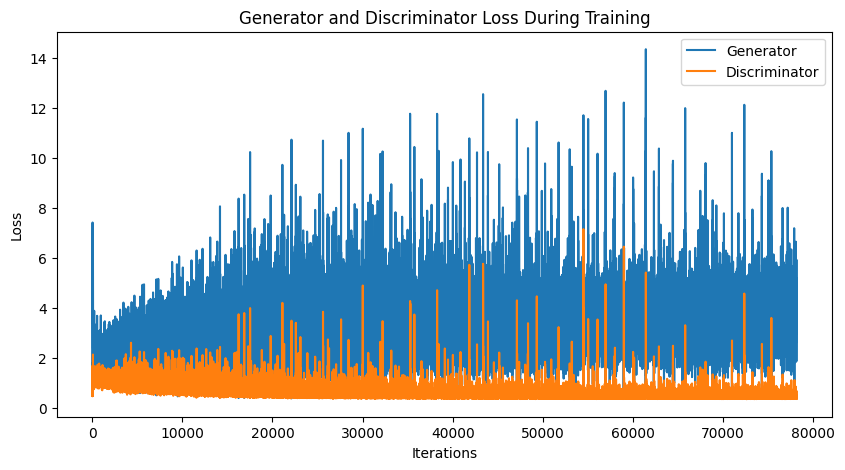

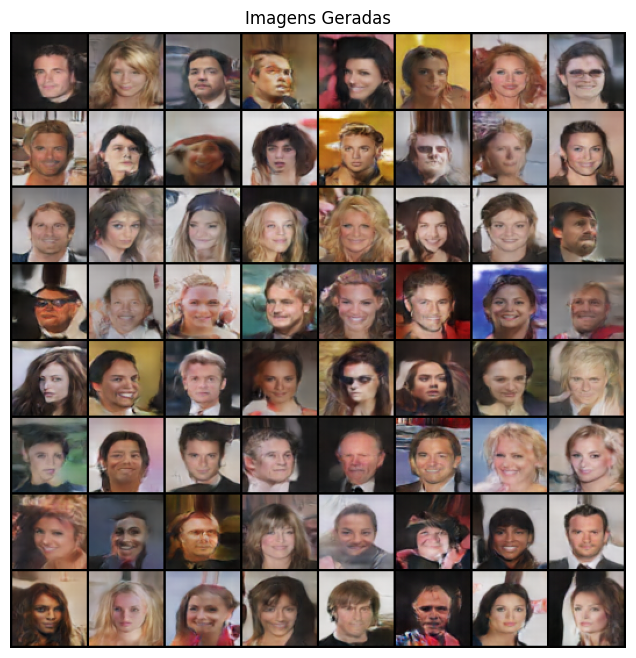

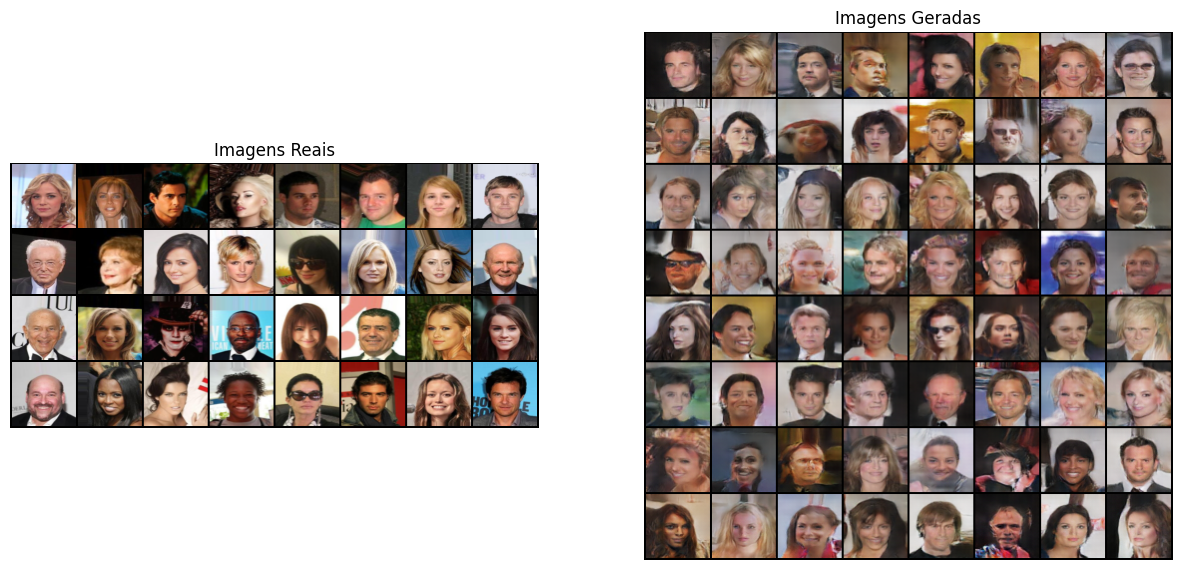

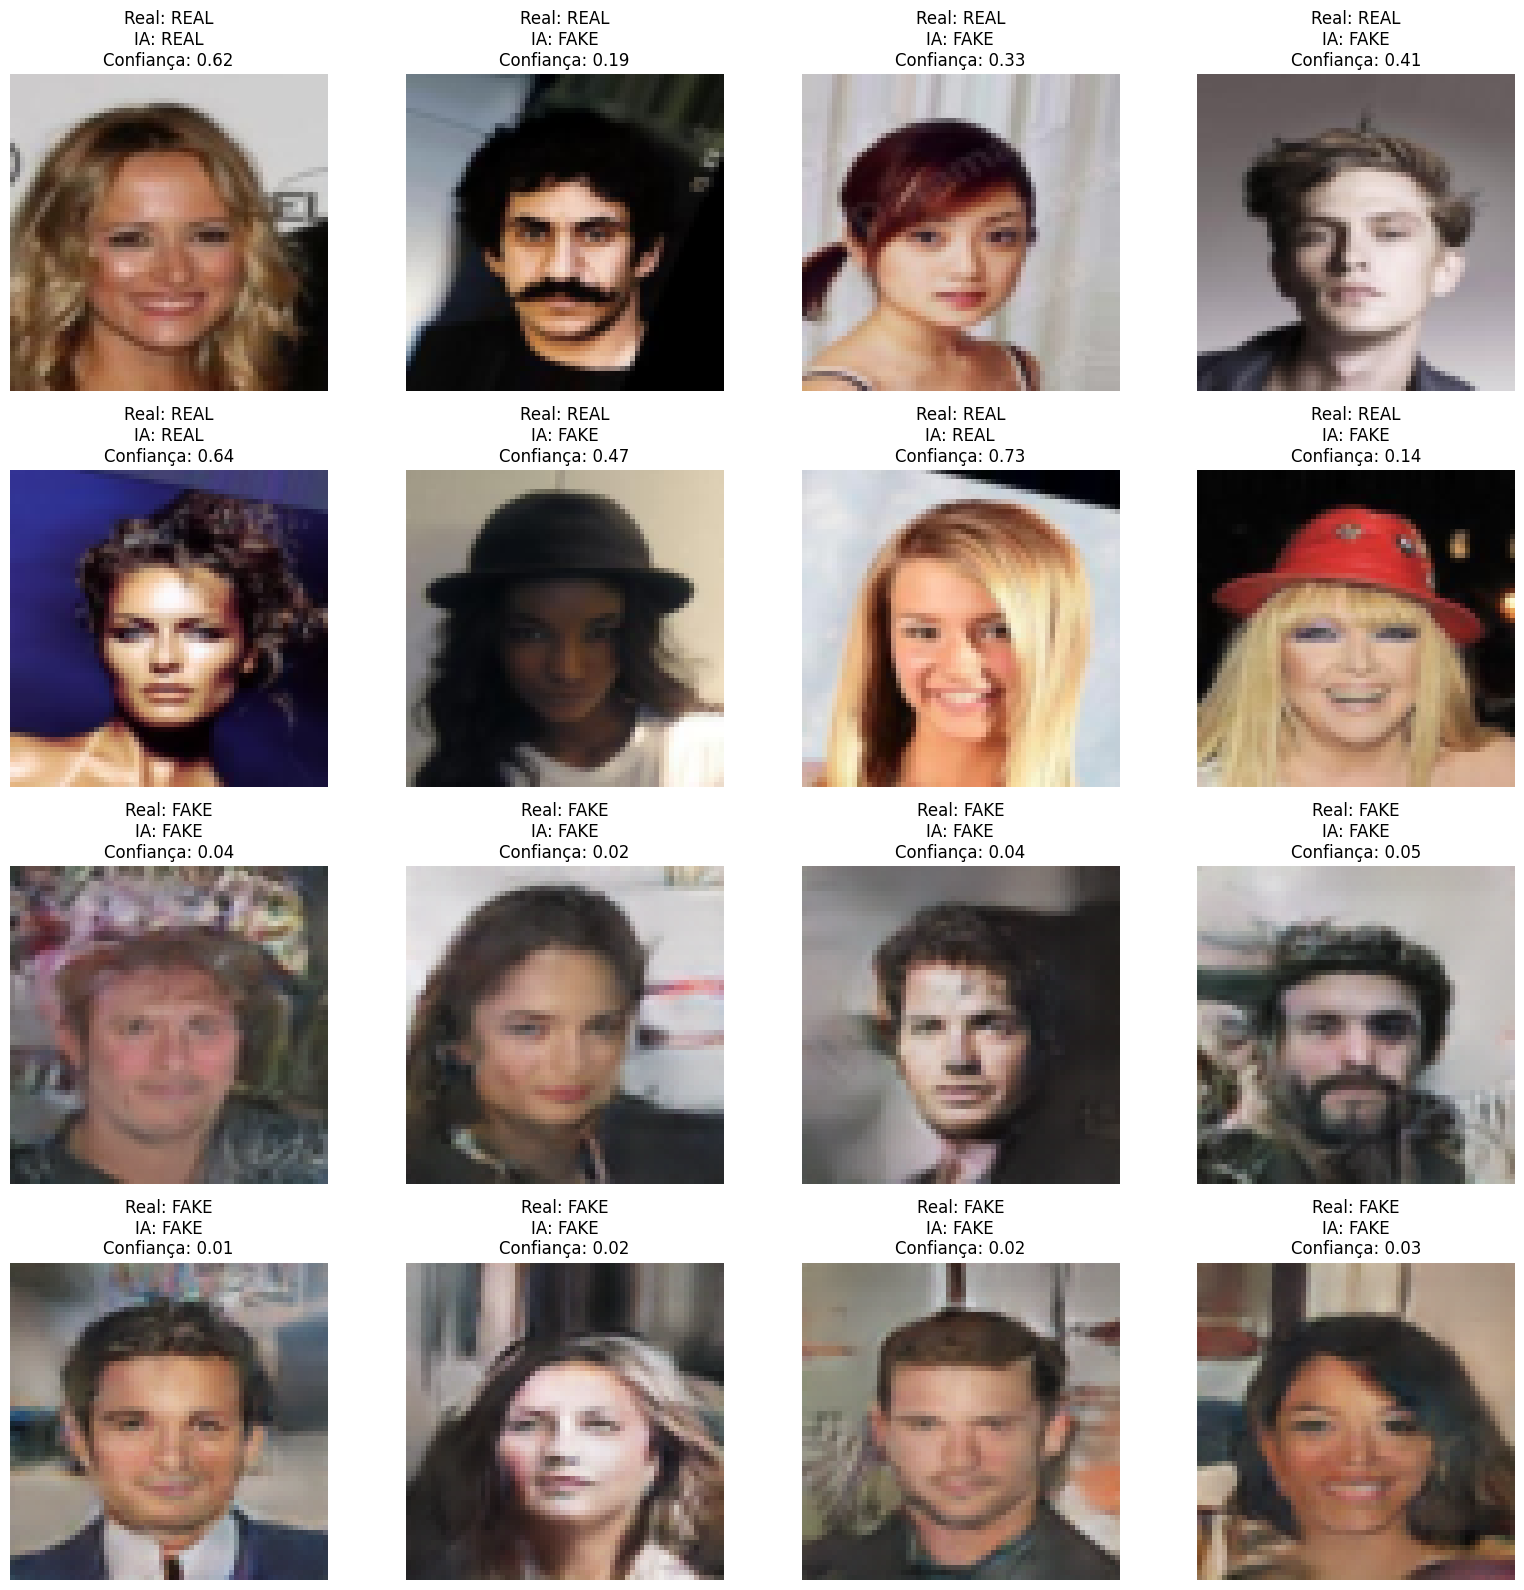

In [4]:
# --- Execução do pipeline ---
prepare_dataset(SOURCE_DATASET, WORKING_ROOT, WORKING_DATA, N_IMAGES_SAMPLE)
dataloader = build_dataloader(WORKING_ROOT, IMAGE_SIZE, BATCH_SIZE)
real_batch = next(iter(dataloader))[0]

net_g = Generator().to(DEVICE)
net_d = Discriminator().to(DEVICE)

g_losses, d_losses, img_list = train(net_g, net_d, dataloader, NUM_EPOCHS, LATENT_DIM, DEVICE)

plot_losses(g_losses, d_losses)
plot_generated(img_list)
plot_real_vs_generated(real_batch, img_list)
test_discriminator(net_d, net_g, dataloader, LATENT_DIM, DEVICE)